### Research and Report Hierarchical Agent Teams System

A supervisor agent's work is to route between different work nodes. But when job becomes complex or there is a large number of workers it becomes difficult for the supervisor to effectively call the correct worker node.

For such cases hierarchically distributed architecture works best. We can build this by composing different sub-graphs and creating a top-level supervisor along with mid-level supervisors.

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()
from langchain_openai import ChatOpenAI
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_community.document_loaders import WebBaseLoader
from langchain_core.tools import tool

llm = ChatOpenAI(model='o3-mini')

USER_AGENT environment variable not set, consider setting it to identify your requests.


## Building Research Team Tools

In [2]:
tavily_tool = TavilySearchResults(max_results = 5)

In [10]:
from typing import Annotated, TypedDict, Literal, Any
from langchain_core.language_models.chat_models import BaseChatModel
from langgraph.graph import MessagesState, MessageGraph, START,END, StateGraph
from langgraph.types import Command

class State(MessagesState):
    next: str

# def make_research_supervisor(llm:BaseChatModel, members: list[str]) -> str:
#     print('<-- Research Supervisor -->')
    
#     node_members = members + ['FINISH']
#     print(node_members)

In [19]:
members = ['general_researcher','finance_researcher','FINISH']
system_prompt = f"""
        You are a supervisor managing a task delegation system with the following workers: {members}.

        Your job is to decide which worker should act next based on the user’s input.

        Guidelines:
        - Carefully read the user’s message.
        - If the message clearly requires a specific action (e.g., search, compute, rewrite), assign it to the appropriate worker.
        - If the message is related to finance return finance_researcher.
        - If the message is realted to general research return general_researcher
        - Once all the tasks are completed respond with FINISH
        - Do **not** invent tasks or assign actions unless the message clearly demands it.

        Each worker will return results after completing their task.
        Once all necessary tasks are completed, end the flow by responding with `FINISH`.

        Be strict — if the message is casual, rhetorical, or lacks a clear task, reply with `FINISH`."""
        
    
class Router(TypedDict):
    next: Literal['general_researcher','finance_researcher','FINISH']
        
    
def research_supervisor(state:State) -> Command[Literal['general_researcher','finance_researcher','__end__']]:
    print('<-- Researcher Supervisor -->')
    
    messages = [{'role':'system','content':system_prompt}] + state['messages']
    
    response = llm.with_structured_output(Router).invoke(messages)
    
    goto = response['next']
    
    print("*********Below is my GOTO*****************")
    
    print(goto)
    
    if goto =='FINISH':
        goto=END
    
    return Command(goto=goto, update={'next':goto})



##### Research Agents

In [38]:
from langchain import hub
from langgraph.prebuilt import create_react_agent
from langchain_core.messages import HumanMessage, AIMessage


def general_research(state:State) -> Command[Literal['supervisor']]:
    print('<-- General Researcher -->')
    
    prompt = 'You are a researcher who researches on general topics only.Do a through research on the query provided'
    tavily_agent = create_react_agent(llm, tools= [tavily_tool],prompt=prompt)
    
    result = tavily_agent.invoke(state)
    return Command(
        goto='supervisor',
        update={'messages':[HumanMessage(content=result['messages'][-1].content, name='general_researcher')]}
    )

In [39]:
from langchain_community.tools.yahoo_finance_news import YahooFinanceNewsTool
from langchain_core.prompts import PromptTemplate

yfinance  =YahooFinanceNewsTool()

def finance_research(state:State) -> Command[Literal['supervisor']]:
    print('<-- Finance Researcher -->')
    
    prompt = "You are a researcher who is an expert on Financial Topics only. Do a through research on the query provided."
            
    yfinance_agent = create_react_agent(llm,tools=[yfinance], prompt=prompt)
    print(state)
    
    response = yfinance_agent.invoke(state)
    
    return Command(
        goto='supervisor',
        update={'messages':[HumanMessage(content=response['messages'][-1].content, name='finance_researcher')]}
    )
    
#research_supervisor_node = make_research_supervisor(llm,['general_researcher','finance_researcher'])

In [41]:
## Building Research Graph

research_builder = StateGraph(State)
research_builder.add_node('supervisor', research_supervisor)
research_builder.add_node('general_researcher', general_research)
research_builder.add_node('finance_researcher',finance_research)

## Logic
research_builder.add_edge(START,'supervisor')

## Compile
research_app = research_builder.compile()

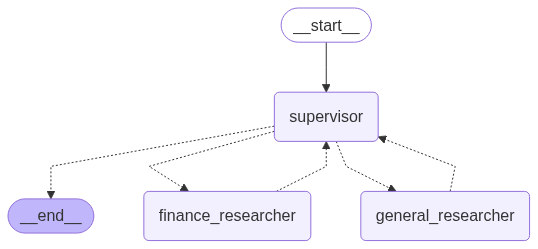

In [42]:
research_app

In [49]:
message = [HumanMessage(content="How did Nvidia stock has performed against Micorsoft in last 1 year")]
response = research_app.invoke({'messages':message})
print(response)

<-- Researcher Supervisor -->
*********Below is my GOTO*****************
finance_researcher
<-- Finance Researcher -->
{'messages': [HumanMessage(content='How did Nvidia stock has performed against Micorsoft in last 1 year', additional_kwargs={}, response_metadata={}, id='7aee14c1-e09d-4b0c-a4fe-0915f2805928')], 'next': 'finance_researcher'}
<-- Researcher Supervisor -->
*********Below is my GOTO*****************
FINISH
{'messages': [HumanMessage(content='How did Nvidia stock has performed against Micorsoft in last 1 year', additional_kwargs={}, response_metadata={}, id='7aee14c1-e09d-4b0c-a4fe-0915f2805928'), HumanMessage(content='Over the past year, Nvidia (NVDA) and Microsoft (MSFT) have followed very different growth trajectories, reflecting not only their differing business models but also the market’s reaction to the evolving tech and AI landscape.\n\n1. Nvidia’s Surge Fueled by AI & GPU Demand:\n\u2003 • Nvidia’s stock has benefited immensely from the explosive interest in artif

In [50]:
response['messages'][-1].pretty_print()

================================ Human Message =================================
Name: finance_researcher

Over the past year, Nvidia (NVDA) and Microsoft (MSFT) have followed very different growth trajectories, reflecting not only their differing business models but also the market’s reaction to the evolving tech and AI landscape.

1. Nvidia’s Surge Fueled by AI & GPU Demand:
  • Nvidia’s stock has benefited immensely from the explosive interest in artificial intelligence and the chip shortage dynamics that continued to boost demand for high-performance graphics processing units (GPUs).
  • The company’s leadership in data center and AI accelerator markets meant that investors were willing to pay a premium for its future growth prospects.
  • As a result, Nvidia’s share price experienced a dramatic rally—marked by significant percentage gains over the last 12 months. (Investors observed that the bullish sentiment on AI, along with strong quarterly earnings, helped drive this rapid app

#### Document Writing Team

In [ ]:
from pathlib import Path
from tempfile import TemporaryDirectory
from typing import Dict, Optional
from langchain_experimental.utilities import PythonREPL

_TEMP_DIRECTORY_ = TemporaryDirectory()
